# Matplotlib

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

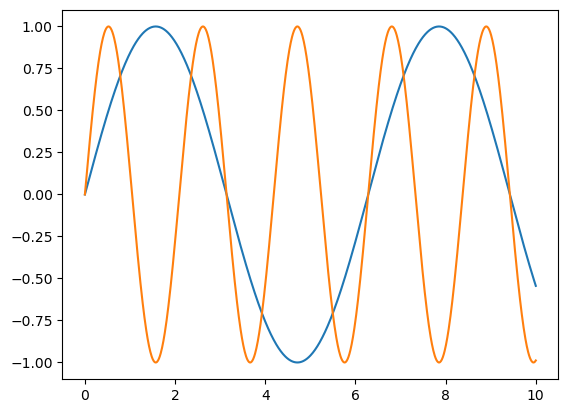

In [7]:
x = np.linspace(0, 10, 1000)
y = np.sin(x)
y2 = np.sin(3*x)

plt.plot(x, y)

plt.plot(x, y2)
plt.show()

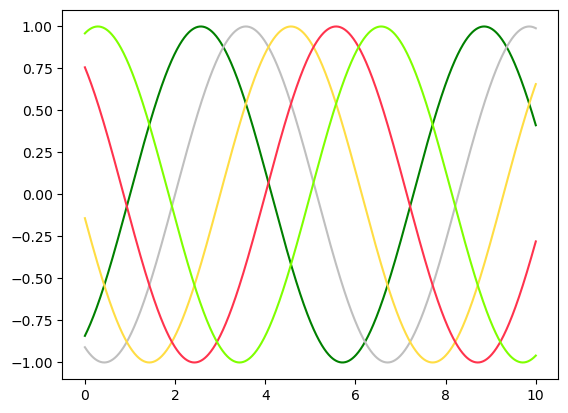

In [3]:
plt.plot(x, np.sin(x - 1), color='g')           # short color code (rgbcmyk)
plt.plot(x, np.sin(x - 2), color='0.75')        # Grayscale between 0 and 1
plt.plot(x, np.sin(x - 3), color='#FFDD44')     # Hex code (RRGGBB from 00 to FF)
plt.plot(x, np.sin(x - 4), color=(1.0,0.2,0.3)) # RGB tuple, values 0 to 1
plt.plot(x, np.sin(x - 5), color='chartreuse') # all HTML color names supported

plt.show()

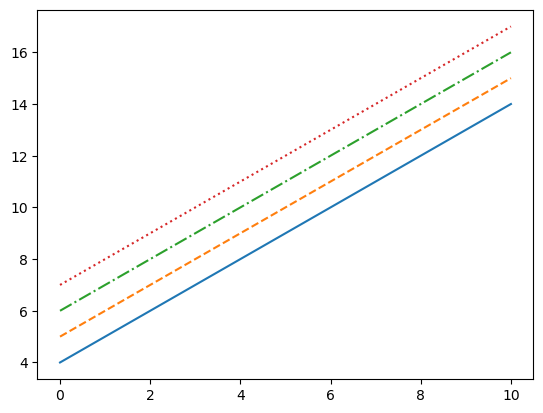

In [9]:
plt.plot(x, x + 4, linestyle='-')  # solid
plt.plot(x, x + 5, linestyle='--') # dashed
plt.plot(x, x + 6, linestyle='-.') # dashdot
plt.plot(x, x + 7, linestyle=':');  # dotted
plt.show()

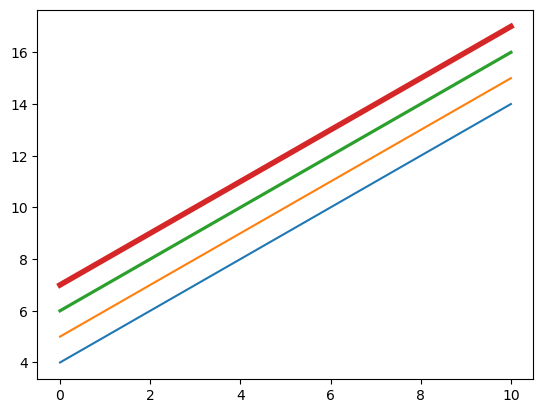

In [ ]:
plt.plot(x, x + 4)
plt.plot(x, x + 5)
plt.plot(x, x + 6, linewidth=2.3) # dashdot
plt.plot(x, x + 7, linewidth=4); 
plt.show()

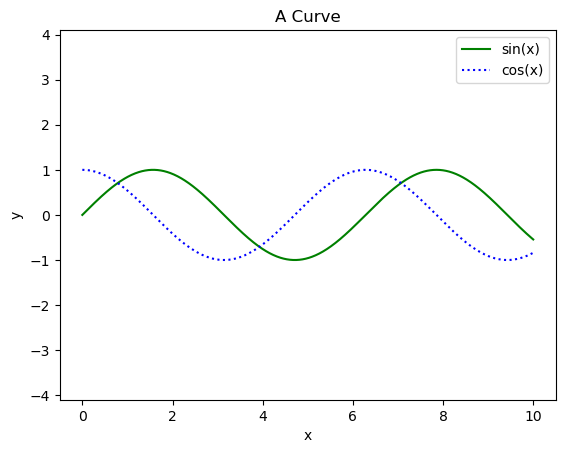

In [11]:
plt.plot(x, np.sin(x), '-g', label='sin(x)')
plt.plot(x, np.cos(x), ':b', label='cos(x)')


plt.axis('equal')
plt.title("A Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [13]:
x.max()

10.0

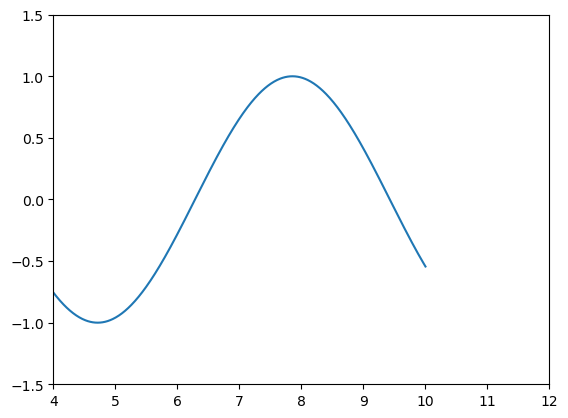

In [15]:
plt.plot(x, np.sin(x))

plt.xlim(4, 12)
plt.ylim(-1.5, 1.5)
plt.show()

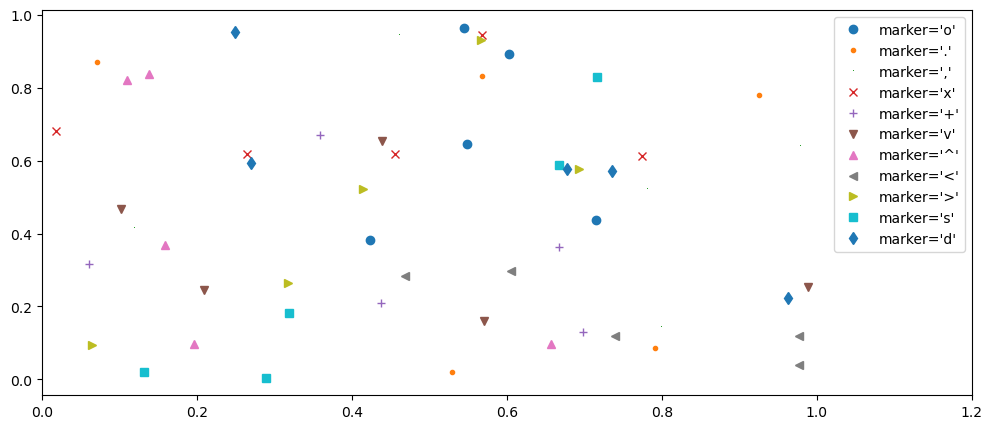

In [17]:
rng = np.random.RandomState(0)

plt.subplots(figsize=(12, 5))
for marker in ['o', '.', ',', 'x', '+', 'v', '^', '<', '>', 's', 'd']:
    plt.plot(rng.rand(5), rng.rand(5), marker,
             label="marker='%s'" % marker)
plt.legend(numpoints=1)
plt.xlim(0, 1.2)
plt.show()

## Накопительный итог

Создав три случайных временных ряда, мы определили один рисунок `fig`, содержащий одну ось `ax`.

Мы вызываем методы `ax` напрямую, чтобы создать диаграмму со сложенными областями и добавить легенду, заголовок и метку оси `y`. При объектно-ориентированном подходе понятно, что все это - атрибуты `ax`.

`tight_layout()` применяется к объекту `Figure` в целом для очистки пробельных элементов

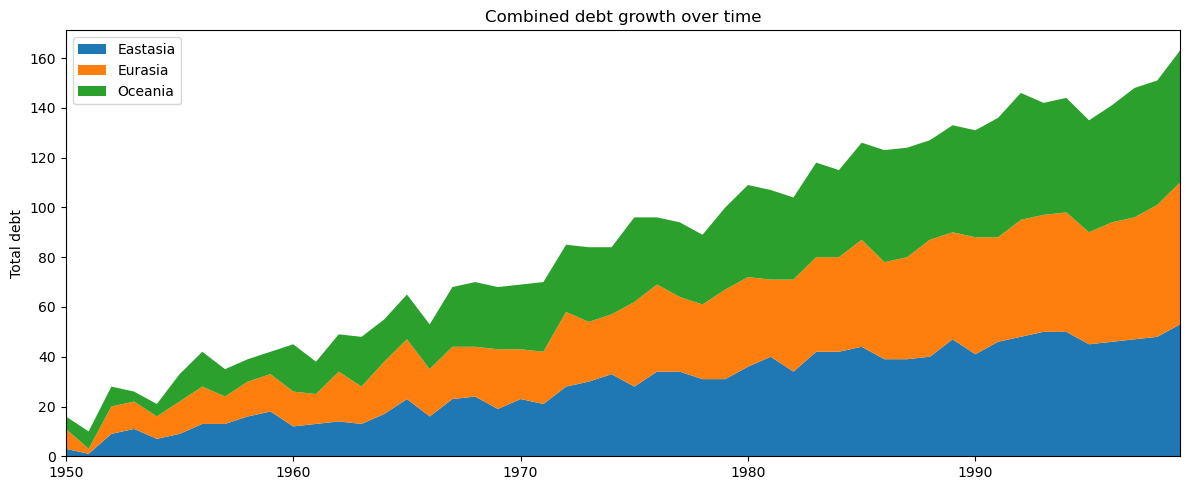

In [9]:
rng = np.arange(50)
rnd = np.random.randint(0, 10, size=(3, rng.size))
yrs = 1950 + rng

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(yrs, rng + rnd, labels=['Eastasia', 'Eurasia', 'Oceania'])
ax.set_title('Combined debt growth over time')
ax.legend(loc='upper left')
ax.set_ylabel('Total debt')
ax.set_xlim(xmin=yrs[0], xmax=yrs[-1])
fig.tight_layout()

## Два графика

В этом примере происходит немного больше:

Поскольку мы создаем фигуру "1x2", возвращаемый результат `plt.subplots(1, 2)` теперь представляет собой объект `Figure` и массив `NumPy` объектов `Axes`. Вы можете проверить это с помощью `fig, axs = plt.subplots(1, 2)` и взглянуть на `axs`.

Мы работаем с `ax1` и `ax2` по отдельности. Последняя строка - хорошая иллюстрация иерархии объектов, где мы изменяем ось `yaxis`, принадлежащую только второй `Axes`, размещая ее тики и метки справа.

Текст внутри знаков доллара использует разметку $\LaTeX$ для выделения переменных курсивом.

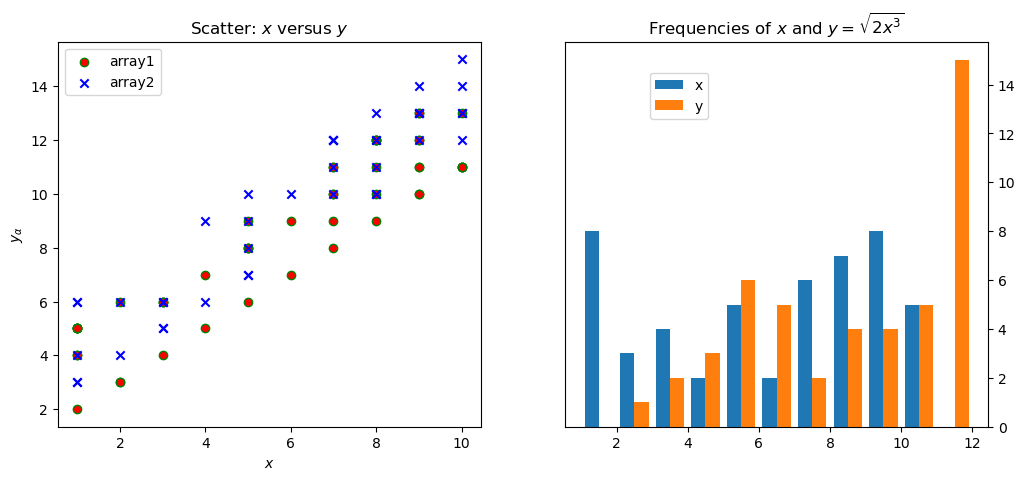

In [26]:
x = np.random.randint(low=1, high=11, size=50)
y = x + np.random.randint(1, 5, size=x.size)
y1 = x + np.random.randint(2, 6, size=x.size)
data = np.column_stack((x, y))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2,
                                figsize=(12, 5))

ax1.scatter(x=x, y=y, marker='o', color='r', edgecolor='g', label='array1')
ax1.scatter(x=x[:40], y=y1[:40], marker='x', color='b', label='array2')
ax1.set_title('Scatter: $x$ versus $y$')
ax1.set_xlabel('$x$')
ax1.set_ylabel(r'$y_\alpha$')
ax1.legend()

ax2.hist(data, bins=np.arange(data.min(), data.max()),
        label=('x', 'y'))
ax2.legend(loc=(0.2, 0.8))
ax2.set_title('Frequencies of $x$ and $y=\sqrt{2x^3}$')
ax2.yaxis.tick_right()

# Seaborn

In [28]:
import seaborn as sns
import pandas as pd


In [14]:
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])

In [15]:
data.head()

,x,y
0,-3.314703,-1.825853
1,-1.286473,-0.373132
2,0.815331,0.253532
3,-5.409529,-1.510623
4,-2.092078,0.379301


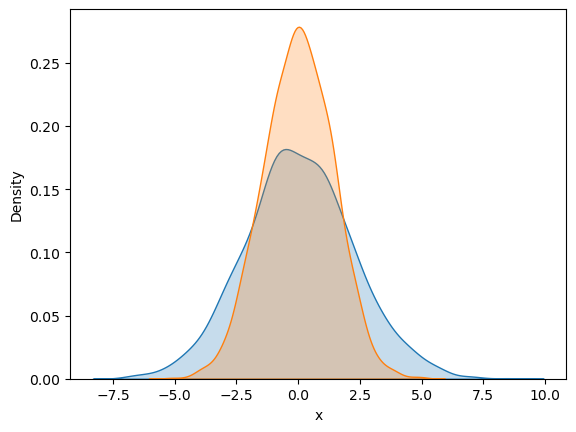

In [16]:
for col in 'xy':
    sns.kdeplot(data[col], fill=True)

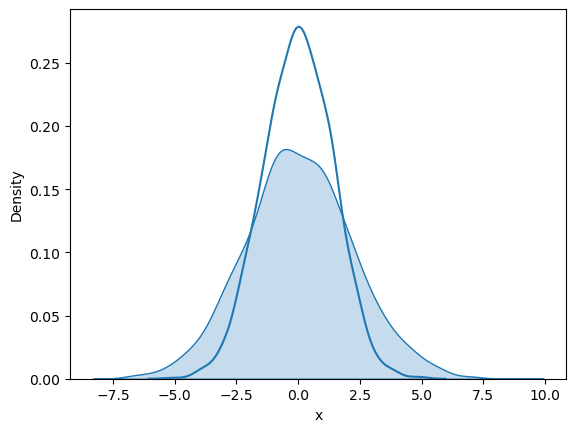

In [17]:
sns.kdeplot(data['x'], fill=True)
sns.kdeplot(data['y'], fill=False);

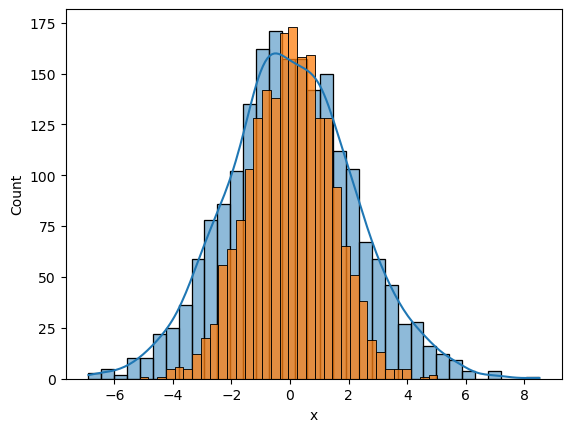

In [18]:
sns.histplot(data['x'], kde=True);
sns.histplot(data['y']);

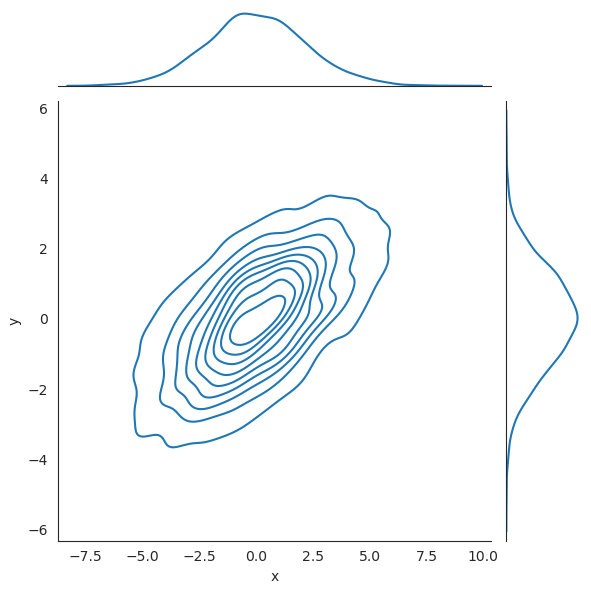

In [19]:
with sns.axes_style('white'):
    sns.jointplot(data=data, x='x', y='y', kind='kde');

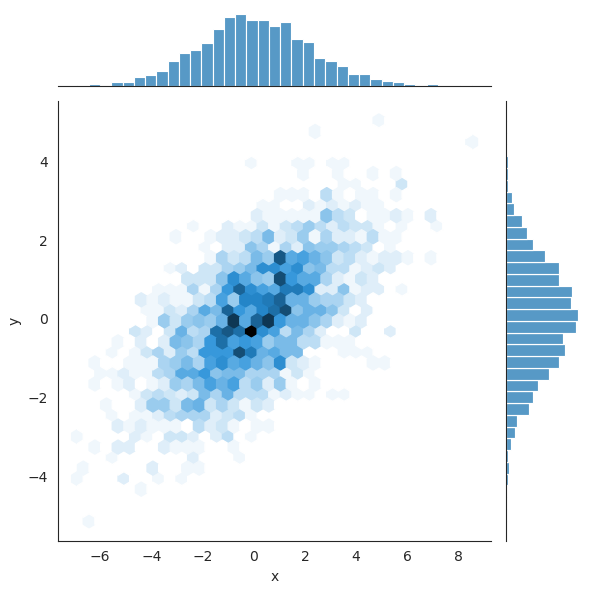

In [20]:
with sns.axes_style('white'):
    sns.jointplot(data=data, x='x', y='y', kind='hex')

**pair plots**

In [30]:
iris = sns.load_dataset("iris")
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [31]:
iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

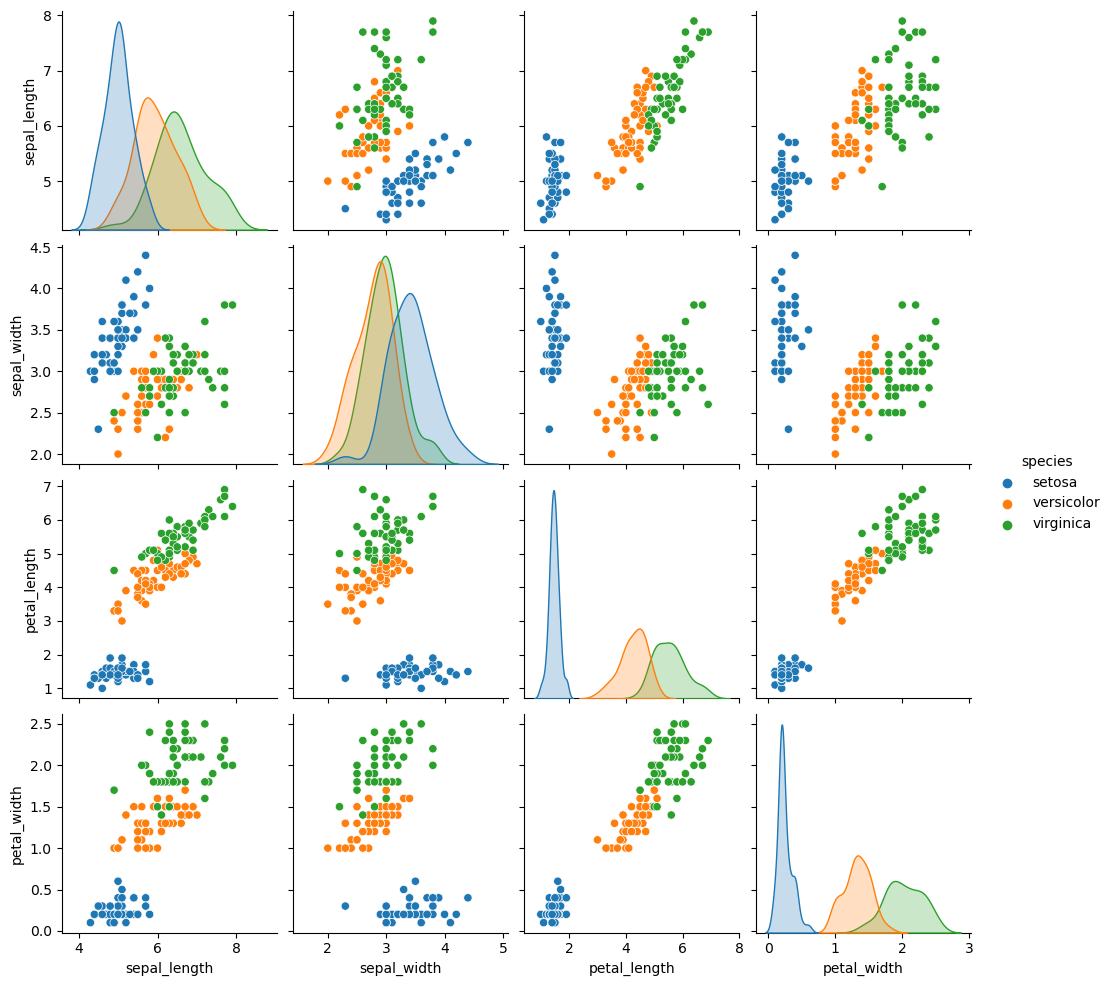

In [32]:
sns.pairplot(iris, hue='species', height=2.5)

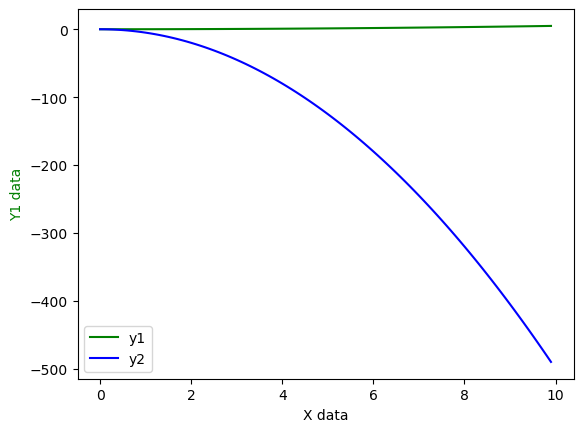

In [35]:
x = np.arange(0, 10, 0.1)
y1 = 0.05 * x**2
y2 = -100 *y1

fig, ax1 = plt.subplots()

# ax2 = ax1.twinx()

ax1.plot(x, y1, 'g-', label='y1')
ax1.plot(x, y2, 'b-', label='y2')

ax1.set_xlabel('X data')
ax1.set_ylabel('Y1 data', color='g')
# ax2.set_ylabel('Y2 data', color='b')
plt.legend()
plt.show()

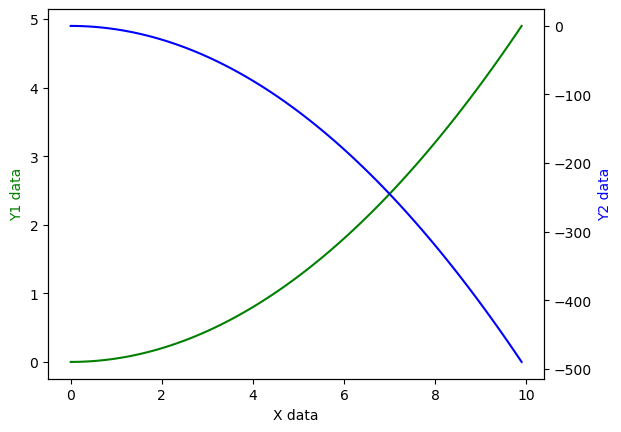

In [24]:
x = np.arange(0, 10, 0.1)
y1 = 0.05 * x**2
y2 = -100 *y1

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(x, y1, 'g-', label='y1')
ax2.plot(x, y2, 'b-', label='y2')

ax1.set_xlabel('X data')
ax1.set_ylabel('Y1 data', color='g')
ax2.set_ylabel('Y2 data', color='b')

plt.show()